In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn modules
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('institutional_energy_data.csv', parse_dates=['timestamp'])

print(f' Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'   Date range:    {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'   Missing values: {df.isnull().sum().sum()}')
print(f'   Duplicates:     {df.duplicated().sum()}')
df.head(10)


✅ Dataset loaded: 26,330 rows, 15 columns
   Date range:    2021-01-01 00:00:00 → 2023-12-31 23:00:00
   Missing values: 288
   Duplicates:     50


,timestamp,hour,day_of_week,month,is_weekday,in_semester,is_event_day,students_present,temperature_C,humidity_pct,appliances_on,floor_util_pct,hvac_load,solar_gen_kwh,energy_kwh
0,2021-01-01 00:00:00,0,4,1,1,1,0,164.0,8.00,58.6,20.0,41.1,5.39,0.00,27.127
1,2021-01-01 01:00:00,1,4,1,1,1,0,154.0,8.00,56.2,16.0,26.3,4.88,0.00,25.220
2,2021-01-01 02:00:00,2,4,1,1,1,1,100.0,8.00,53.5,17.0,30.3,5.41,0.00,29.419
3,2021-01-01 03:00:00,3,4,1,1,1,0,203.0,10.26,55.1,24.0,41.4,4.34,0.00,30.731
4,2021-01-01 04:00:00,4,4,1,1,1,0,120.0,8.87,51.4,13.0,35.5,4.85,0.00,28.663
5,2021-01-01 05:00:00,5,4,1,1,1,0,167.0,10.32,52.4,17.0,34.9,4.63,0.00,21.467
6,2021-01-01 06:00:00,6,4,1,1,1,0,112.0,14.59,51.8,15.0,28.2,2.97,0.00,23.911
7,2021-01-01 07:00:00,7,4,1,1,1,0,249.0,14.93,50.0,21.0,36.0,3.06,0.00,23.469
8,2021-01-01 08:00:00,8,4,1,1,1,0,653.0,14.52,56.0,57.0,73.2,2.91,1.50,45.816
9,2021-01-01 09:00:00,9,4,1,1,1,0,569.0,17.28,52.9,46.0,60.7,1.82,1.52,42.056


In [3]:
print("=" * 55)
print("STEP 2: DATA PREPROCESSING")
print("=" * 55)

print("\n Dataset Shape:", df.shape)
print("\n Data Types:")
print(df.dtypes)

print("\n Statistical Summary:")
df.describe().round(2)

STEP 2: DATA PREPROCESSING

📋 Dataset Shape: (26330, 15)

📌 Data Types:
timestamp           datetime64[ns]
hour                         int64
day_of_week                  int64
month                        int64
is_weekday                   int64
in_semester                  int64
is_event_day                 int64
students_present           float64
temperature_C              float64
humidity_pct               float64
appliances_on              float64
floor_util_pct             float64
hvac_load                  float64
solar_gen_kwh              float64
energy_kwh                 float64
dtype: object

📌 Statistical Summary:


,timestamp,hour,day_of_week,month,is_weekday,in_semester,is_event_day,students_present,temperature_C,humidity_pct,appliances_on,floor_util_pct,hvac_load,solar_gen_kwh,energy_kwh
count,26330,26330.00,26330.00,26330.00,26330.00,26330.00,26330.00,26278.00,26225.00,26251.00,26278.00,26330.00,26330.00,26330.00,26330.00
mean,2022-07-02 09:04:50.543106816,11.50,3.01,6.53,0.71,0.66,0.03,193.13,22.06,56.29,21.22,35.48,2.82,0.89,27.46
min,2021-01-01 00:00:00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,8.00,20.00,0.00,5.00,0.02,0.00,2.23
25%,2021-10-01 16:15:00,5.00,1.00,4.00,0.00,0.00,0.00,36.00,15.68,46.60,11.00,22.80,1.57,0.00,19.99
50%,2022-07-02 09:30:00,11.00,3.00,7.00,1.00,1.00,0.00,103.00,21.94,53.50,15.00,28.80,2.63,0.00,24.37
75%,2023-04-01 22:45:00,17.00,5.00,10.00,1.00,1.00,0.00,195.00,28.40,64.70,22.00,39.20,4.03,1.90,31.13
max,2023-12-31 23:00:00,23.00,6.00,12.00,1.00,1.00,1.00,749.00,42.87,98.00,62.00,88.00,7.65,4.58,61.15
std,NaN,6.92,2.00,3.45,0.45,0.47,0.17,222.61,8.25,13.52,15.33,18.50,1.50,1.18,10.58


In [4]:
print("\n Missing Values BEFORE cleaning:")
print(df.isnull().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"    Filled '{col}' with median = {median_val:.2f}")

print("\n Missing Values AFTER cleaning:")
print(df.isnull().sum())


🔍 Missing Values BEFORE cleaning:
timestamp             0
hour                  0
day_of_week           0
month                 0
is_weekday            0
in_semester           0
is_event_day          0
students_present     52
temperature_C       105
humidity_pct         79
appliances_on        52
floor_util_pct        0
hvac_load             0
solar_gen_kwh         0
energy_kwh            0
dtype: int64
   ✔ Filled 'students_present' with median = 103.00
   ✔ Filled 'temperature_C' with median = 21.94
   ✔ Filled 'humidity_pct' with median = 53.50
   ✔ Filled 'appliances_on' with median = 15.00

✅ Missing Values AFTER cleaning:
timestamp           0
hour                0
day_of_week         0
month               0
is_weekday          0
in_semester         0
is_event_day        0
students_present    0
temperature_C       0
humidity_pct        0
appliances_on       0
floor_util_pct      0
hvac_load           0
solar_gen_kwh       0
energy_kwh          0
dtype: int64


In [5]:
print(f"\n Duplicate rows BEFORE: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f" Duplicate rows AFTER:  {df.duplicated().sum()}")
print(f"   Dataset shape after cleaning: {df.shape}")


🔍 Duplicate rows BEFORE: 50
✅ Duplicate rows AFTER:  0
   Dataset shape after cleaning: (26280, 15)


In [6]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df.drop(columns=['hour', 'timestamp'], inplace=True, errors='ignore')
print(" 'hour' encoded into 'hour_sin' and 'hour_cos' (cyclic features)")
print("   Original 'hour' and 'timestamp' columns dropped.")

features = [
    'students_present', 'temperature_C', 'appliances_on',
    'is_weekday', 'in_semester', 'is_event_day', 'humidity_pct',
    'floor_util_pct', 'hvac_load', 'solar_gen_kwh',
    'hour_sin', 'hour_cos', 'month', 'day_of_week'
]
target = 'energy_kwh'

X = df[features]
y = df[target]

print(f"\n Features shape: {X.shape}")
print(f" Target shape:   {y.shape}")
print(f"\nFeatures used: {features}")

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features
)

print("\n Features standardized using StandardScaler")
print("\nMean after scaling (should be 0):")
print(X_scaled.mean().round(4))
print("\nStd after scaling (should be 1):")
print(X_scaled.std().round(4))


✅ 'hour' encoded into 'hour_sin' and 'hour_cos' (cyclic features)
   Original 'hour' and 'timestamp' columns dropped.

📐 Features shape: (26280, 14)
🎯 Target shape:   (26280,)

Features used: ['students_present', 'temperature_C', 'appliances_on', 'is_weekday', 'in_semester', 'is_event_day', 'humidity_pct', 'floor_util_pct', 'hvac_load', 'solar_gen_kwh', 'hour_sin', 'hour_cos', 'month', 'day_of_week']

✅ Features standardized using StandardScaler

Mean after scaling (should be ~0):
students_present   -0.0
temperature_C      -0.0
appliances_on      -0.0
is_weekday         -0.0
in_semester        -0.0
is_event_day       -0.0
humidity_pct       -0.0
floor_util_pct     -0.0
hvac_load          -0.0
solar_gen_kwh      -0.0
hour_sin           -0.0
hour_cos           -0.0
month               0.0
day_of_week        -0.0
dtype: float64

Std after scaling (should be ~1):
students_present    1.0
temperature_C       1.0
appliances_on       1.0
is_weekday          1.0
in_semester         1.0
is_event

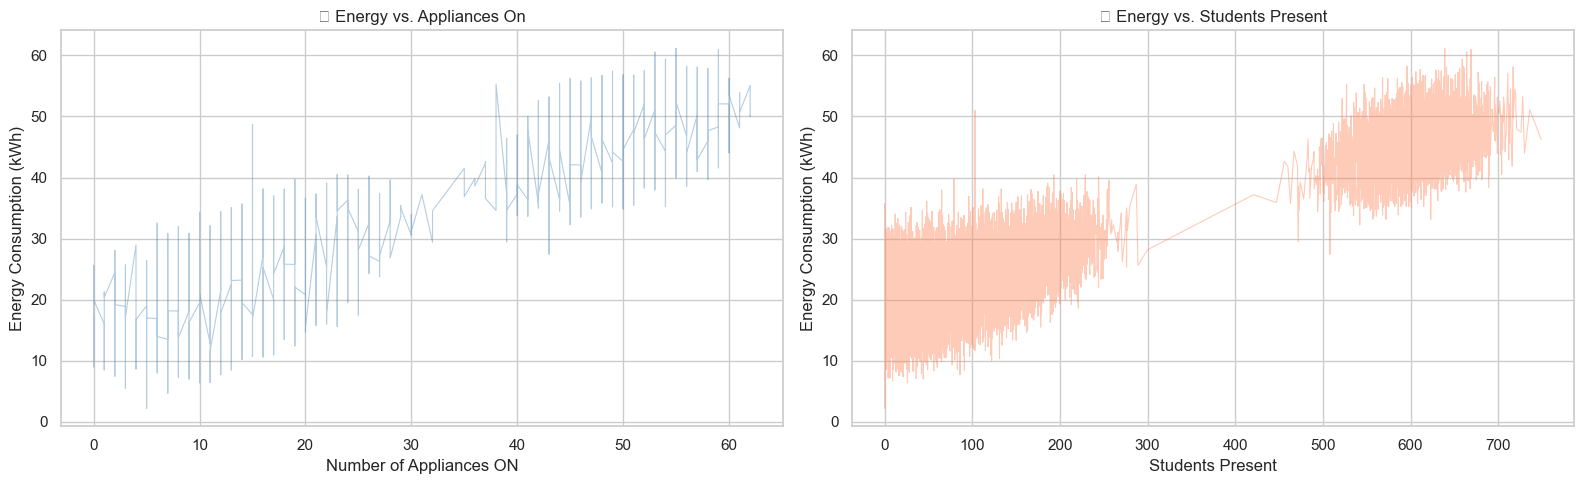


💡 INSIGHT:
   - Energy consumption rises clearly as more appliances are turned on.
   - More students on campus leads to higher energy usage,
     likely due to increased lighting, HVAC, and device charging.



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_df = df.sort_values('appliances_on')
axes[0].plot(sorted_df['appliances_on'], sorted_df['energy_kwh'],
             alpha=0.4, color='steelblue', linewidth=0.8)
axes[0].set_xlabel('Number of Appliances ON')
axes[0].set_ylabel('Energy Consumption (kWh)')
axes[0].set_title('📈 Energy vs. Appliances On')

sorted_df2 = df.sort_values('students_present')
axes[1].plot(sorted_df2['students_present'], sorted_df2['energy_kwh'],
             alpha=0.4, color='coral', linewidth=0.8)
axes[1].set_xlabel('Students Present')
axes[1].set_ylabel('Energy Consumption (kWh)')
axes[1].set_title('📈 Energy vs. Students Present')

plt.tight_layout()
plt.savefig('plot_line.png', dpi=100, bbox_inches='tight')
plt.show()


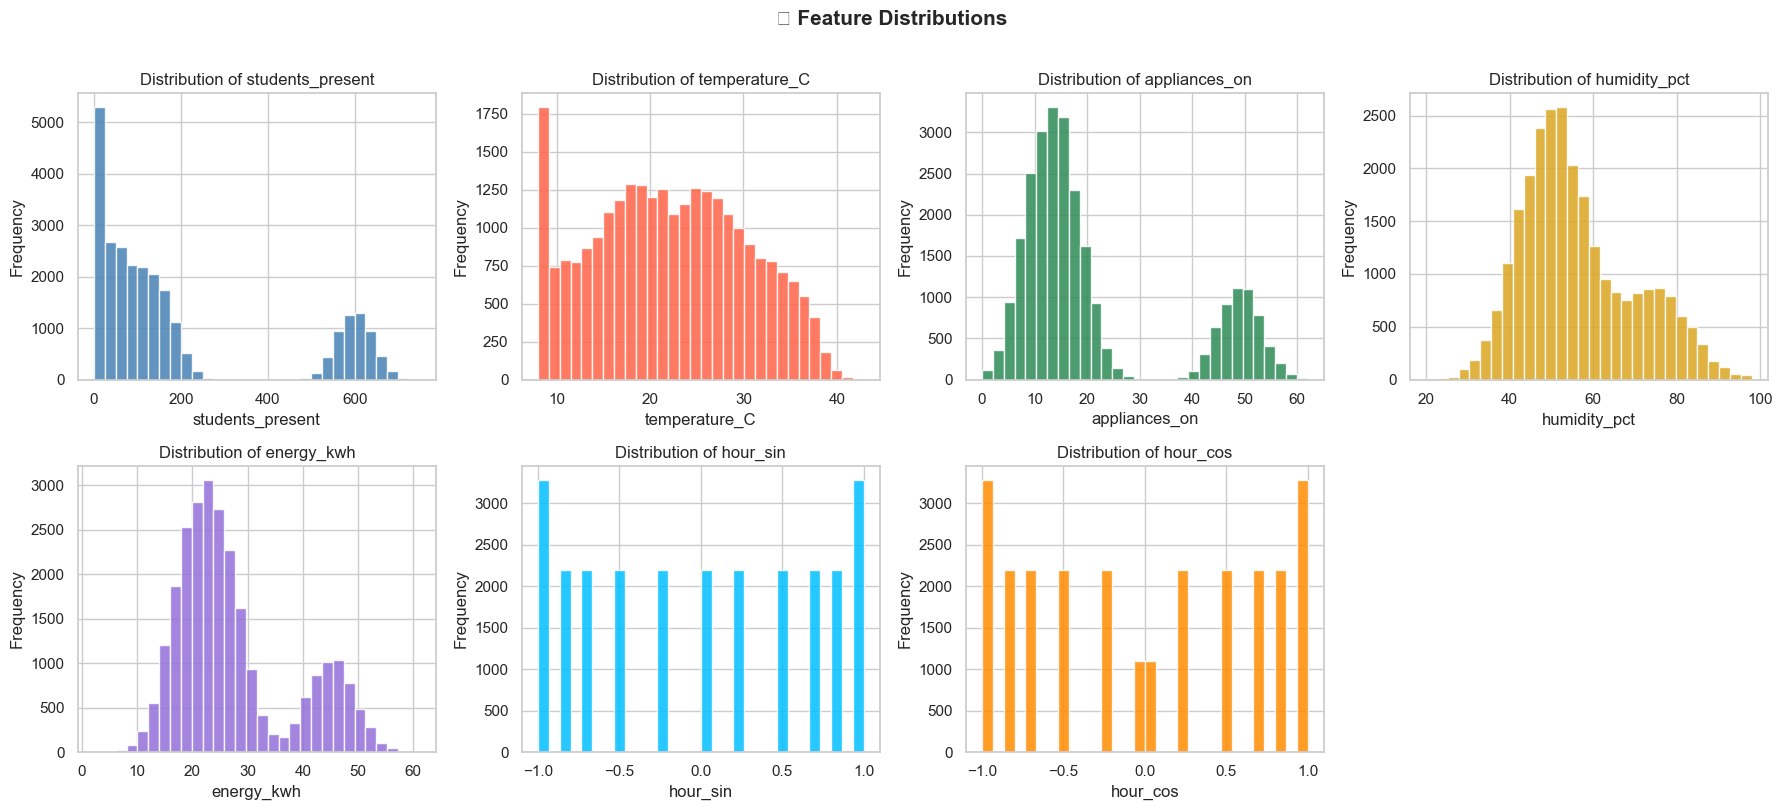


💡 INSIGHT:
   - 'students_present' is right-skewed: many low-attendance hours (nights/weekends).
   - 'energy_kwh' follows a roughly normal distribution centred around 20 kWh.
   - 'temperature_C' and 'humidity_pct' are approximately uniformly distributed.
   - Sine/Cosine hour features show the expected circular distributions.



In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_cols = ['students_present', 'temperature_C', 'appliances_on',
             'humidity_pct', 'energy_kwh', 'hour_sin', 'hour_cos']
colors = ['steelblue', 'tomato', 'seagreen', 'goldenrod',
          'mediumpurple', 'deepskyblue', 'darkorange']

for i, (col, color) in enumerate(zip(plot_cols, colors)):
    axes[i].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)   # Hide the empty 8th subplot
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_histograms.png', dpi=100, bbox_inches='tight')
plt.show()


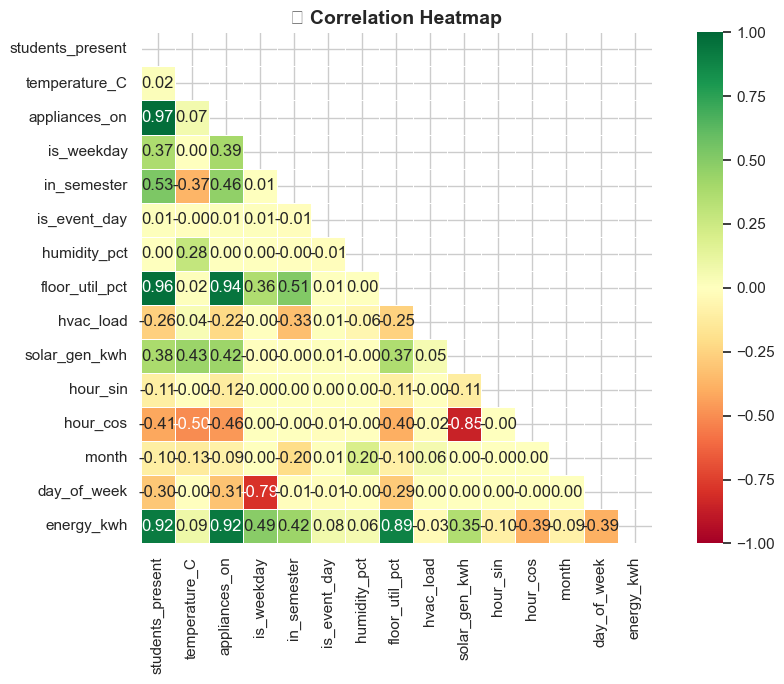


🏆 Top Feature Correlations with 'energy_kwh':
appliances_on       0.924123
students_present    0.917175
floor_util_pct      0.890336
is_weekday          0.487194
in_semester         0.423895
solar_gen_kwh       0.352013
temperature_C       0.087447
is_event_day        0.076658
humidity_pct        0.061030
hvac_load          -0.033974
month              -0.087481
hour_sin           -0.099259
day_of_week        -0.388364
hour_cos           -0.392770
Name: energy_kwh, dtype: float64

💡 INSIGHT:
   - 'appliances_on' has the strongest positive correlation with energy usage.
   - 'students_present' also strongly correlates — more people, more consumption.
   - 'is_weekday' shows moderate positive correlation.
   - 'hour_sin' / 'hour_cos' capture time-based patterns in energy use.



In [9]:
plt.figure(figsize=(10, 7))
corr_matrix = df[features + [target]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Upper triangle mask
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Print top correlations with target
print("\n Top Feature Correlations with 'energy_kwh':")
print(corr_matrix['energy_kwh'].drop('energy_kwh').sort_values(ascending=False))


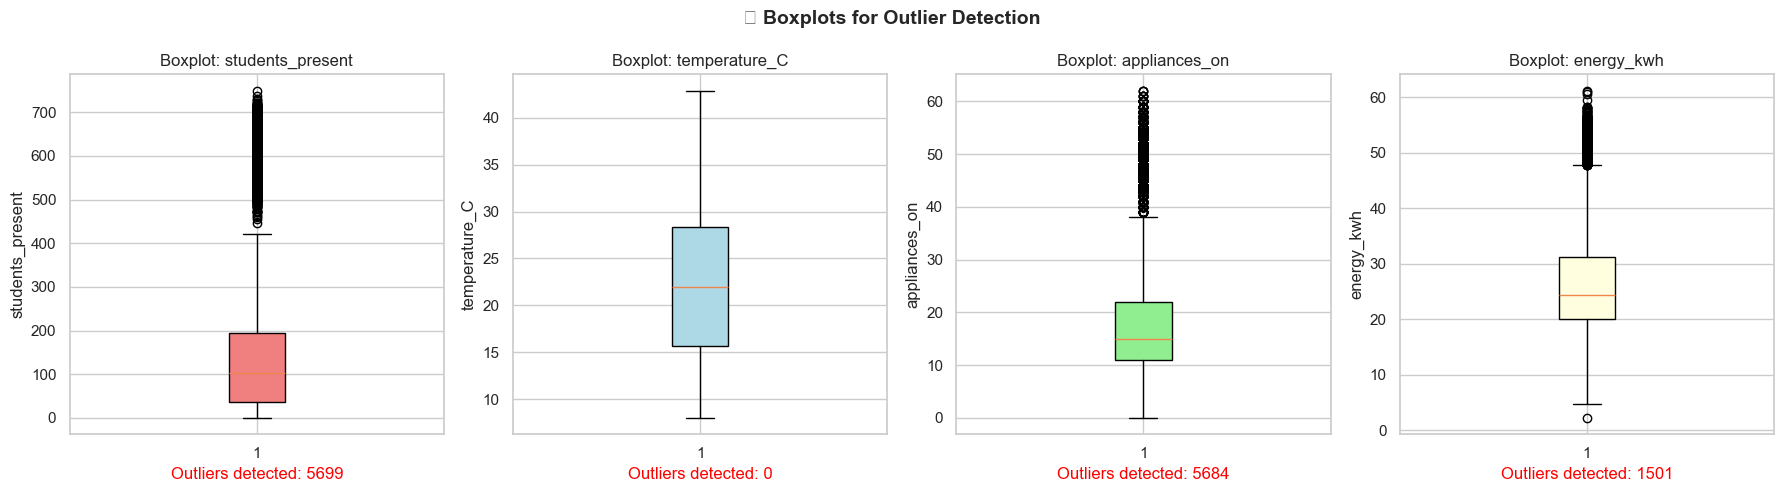


💡 INSIGHT:
   - 'students_present' has a few high outliers (unexpected surges in attendance).
   - 'energy_kwh' shows upper outliers, likely caused by special events or
     equipment running overnight.
   - These outliers are real-world noise and are kept to make the model robust.



In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

boxplot_cols = ['students_present', 'temperature_C', 'appliances_on', 'energy_kwh']
colors = ['lightcoral', 'lightblue', 'lightgreen', 'lightyellow']

for ax, col, color in zip(axes, boxplot_cols, colors):
    bp = ax.boxplot(df[col], patch_artist=True, notch=False)
    bp['boxes'][0].set_facecolor(color)
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel(col)

    # Annotate outlier count
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    ax.set_xlabel(f'Outliers detected: {len(outliers)}', color='red')

plt.suptitle(' Boxplots for Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()


4.1 PCA - Principal Component Analysis


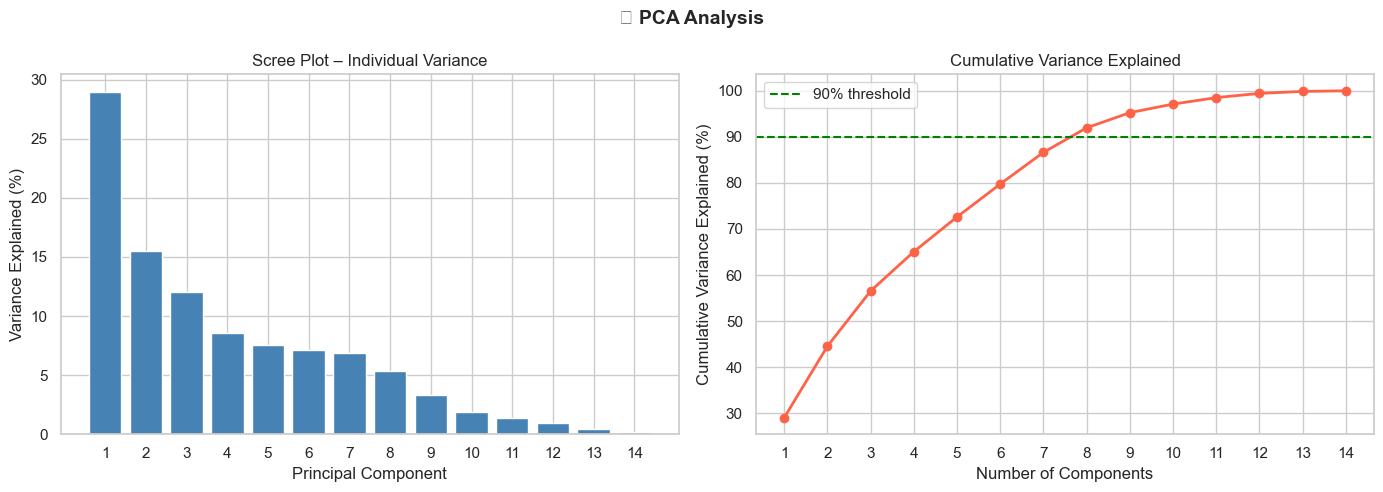


📌 Components needed to explain 90% variance: 8

💡 INSIGHT:
   PCA shows that 8 components capture 90%+ of variance.
   For interpretability, we'll use Backward Elimination for final model.


In [11]:
print("=" * 55)
print("4.1 PCA - Principal Component Analysis")
print("=" * 55)

pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var)+1), explained_var*100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot – Individual Variance')
axes[0].set_xticks(range(1, len(explained_var)+1))

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100,
             'o-', color='tomato', linewidth=2)
axes[1].axhline(y=90, color='green', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_var)+1))

plt.suptitle('PCA Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pca.png', dpi=100, bbox_inches='tight')
plt.show()

n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"\n Components needed to explain 90% variance: {n_components_90}")
print("\n INSIGHT:")
print(f"   PCA shows that {n_components_90} components capture 90%+ of variance.")
print("   For interpretability, we'll use Backward Elimination for final model.")

In [12]:
print("\n" + "=" * 55)
print("4.2 Backward Feature Elimination")
print("=" * 55)

# Split first (before selection to avoid data leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Backward selection using Linear Regression as estimator
lr_selector = LinearRegression()
backward_selector = SequentialFeatureSelector(
    lr_selector,
    n_features_to_select='auto',
    direction='backward',
    scoring='r2',
    cv=5
)
backward_selector.fit(X_train_raw, y_train)

selected_mask = backward_selector.get_support()
selected_features = [f for f, m in zip(features, selected_mask) if m]
removed_features  = [f for f, m in zip(features, selected_mask) if not m]

print(f"\n Selected Features ({len(selected_features)}): {selected_features}")
print(f" Removed Features  ({len(removed_features)}):  {removed_features}")

# Apply feature selection
X_train = X_train_raw[selected_features]
X_test  = X_test_raw[selected_features]



4.2 Backward Feature Elimination

✅ Selected Features (7): ['students_present', 'appliances_on', 'is_weekday', 'is_event_day', 'humidity_pct', 'hvac_load', 'solar_gen_kwh']
❌ Removed Features  (7):  ['temperature_C', 'in_semester', 'floor_util_pct', 'hour_sin', 'hour_cos', 'month', 'day_of_week']

💡 INSIGHT:
   Backward Elimination keeps features that maximise R² in cross-validation.
   Removed features contribute little extra predictive power,
   making the model simpler and less prone to overfitting.



In [13]:
print("=" * 55)
print("STEP 5: MODEL TRAINING")
print("=" * 55)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print(" Linear Regression model trained.")

lr_cv = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')
print(f"   Cross-Validation R² (5-fold): {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

rf_model = RandomForestRegressor(
    n_estimators=200,    # 200 decision trees
    max_depth=10,        # Maximum tree depth
    min_samples_split=5,
    random_state=42,
    n_jobs=-1            # Use all CPU cores
)
rf_model.fit(X_train, y_train)
print("\n Random Forest Regressor trained (200 trees, max_depth=10).")

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print(f"   Cross-Validation R² (5-fold): {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

STEP 5: MODEL TRAINING
✅ Linear Regression model trained.
   Cross-Validation R² (5-fold): 0.9243 ± 0.0023

✅ Random Forest Regressor trained (200 trees, max_depth=10).
   Cross-Validation R² (5-fold): 0.9224 ± 0.0018


In [15]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Compute and print evaluation metrics for a trained model."""
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    metrics = {
        'Model': name,
        'Train R²': r2_score(y_tr, y_pred_train),
        'Test R²':  r2_score(y_te, y_pred_test),
        'MAE':      mean_absolute_error(y_te, y_pred_test),
        'MSE':      mean_squared_error(y_te, y_pred_test),
        'RMSE':     np.sqrt(mean_squared_error(y_te, y_pred_test))
    }
    return metrics, y_pred_test

lr_metrics, lr_preds = evaluate_model('Linear Regression',  lr_model, X_train, X_test, y_train, y_test)
rf_metrics, rf_preds = evaluate_model('Random Forest',       rf_model, X_train, X_test, y_train, y_test)

results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print("\n MODEL EVALUATION RESULTS:")
print(results_df.round(4).to_string())



📊 MODEL EVALUATION RESULTS:
                   Train R²  Test R²     MAE     MSE    RMSE
Model                                                       
Linear Regression    0.9244   0.9239  2.3065  8.4757  2.9113
Random Forest        0.9413   0.9207  2.3619  8.8356  2.9725

💡 INTERPRETATION:
   - Higher R² = Better fit (closer to 1.0 is ideal)
   - Lower MAE/MSE/RMSE = More accurate predictions
   - If Train R² >> Test R²: model may be overfitting



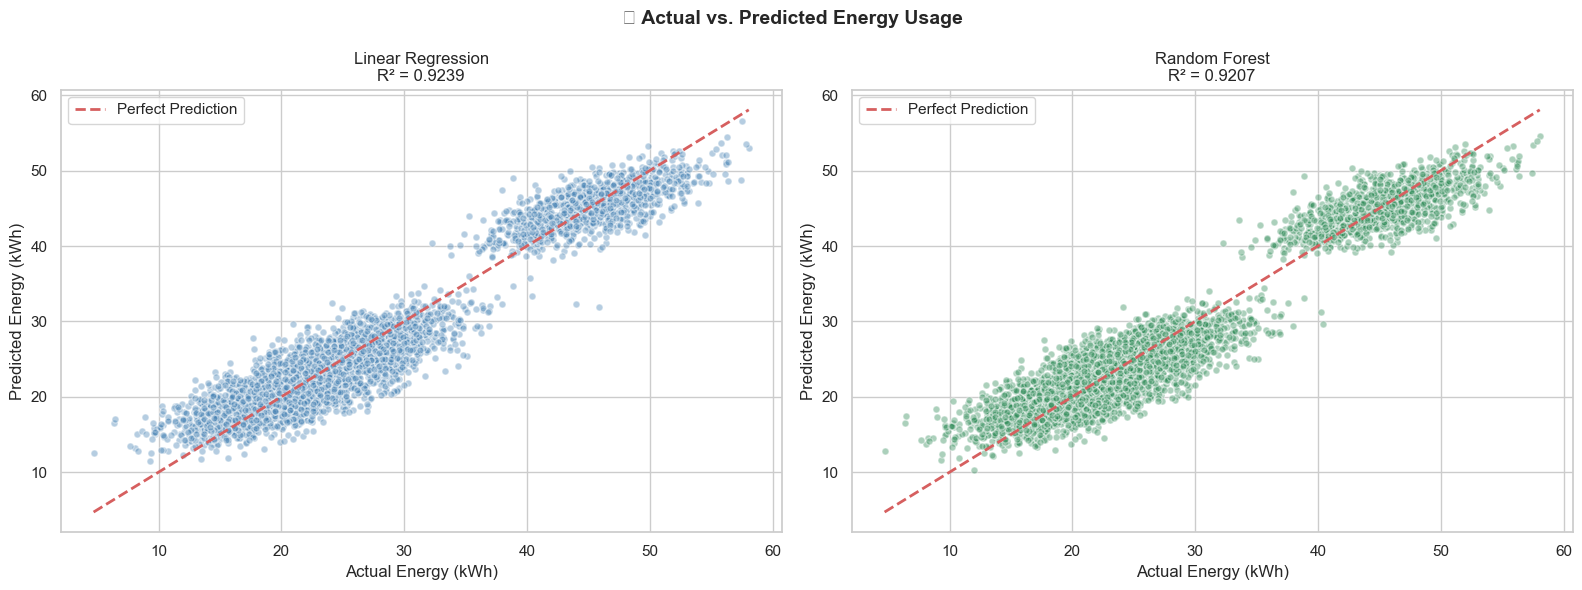

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name, preds, color in [
    (axes[0], 'Linear Regression',  lr_preds, 'steelblue'),
    (axes[1], 'Random Forest',       rf_preds, 'seagreen')
]:
    ax.scatter(y_test, preds, alpha=0.4, color=color, edgecolors='white', s=25)
    # Perfect prediction line
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Energy (kWh)')
    ax.set_ylabel('Predicted Energy (kWh)')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.4f}')
    ax.legend()

plt.suptitle(' Actual vs. Predicted Energy Usage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

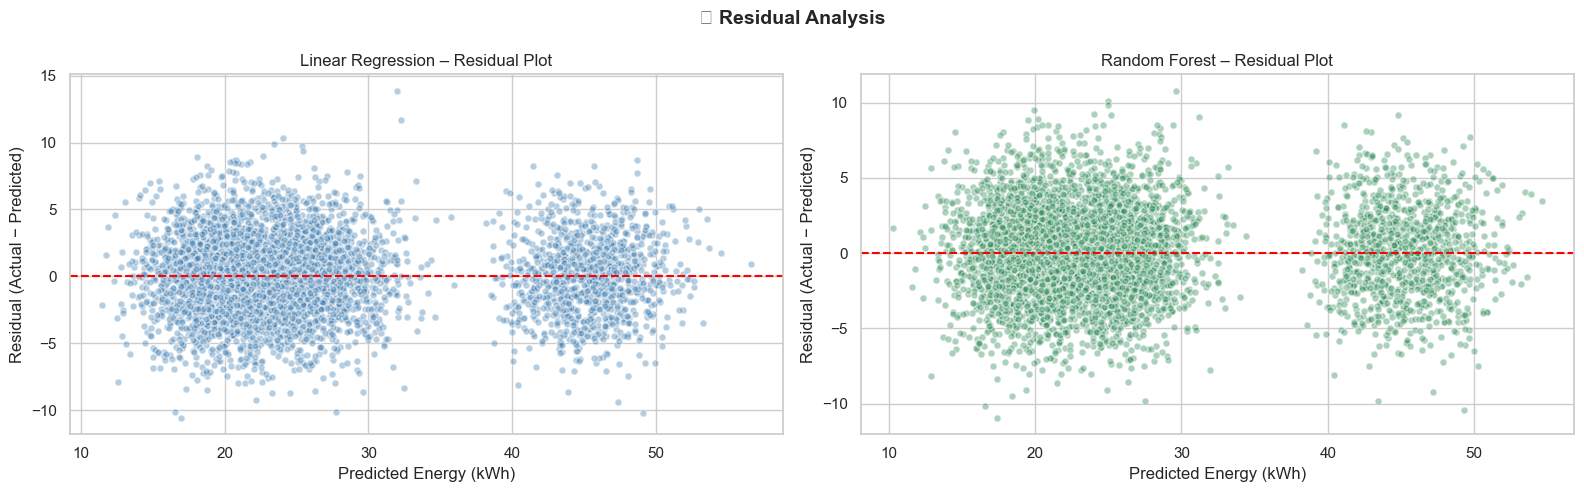


💡 INSIGHT:
   - Residuals should be randomly scattered around zero.
   - Any pattern (funnel shape, curve) indicates model shortcomings.
   - Random Forest residuals tend to be tighter → better fit.



In [17]:
# ── Residual Plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name, preds, color in [
    (axes[0], 'Linear Regression',  lr_preds, 'steelblue'),
    (axes[1], 'Random Forest',       rf_preds, 'seagreen')
]:
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.4, color=color, edgecolors='white', s=25)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Energy (kWh)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'{name} – Residual Plot')

plt.suptitle(' Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_residuals.png', dpi=100, bbox_inches='tight')
plt.show()


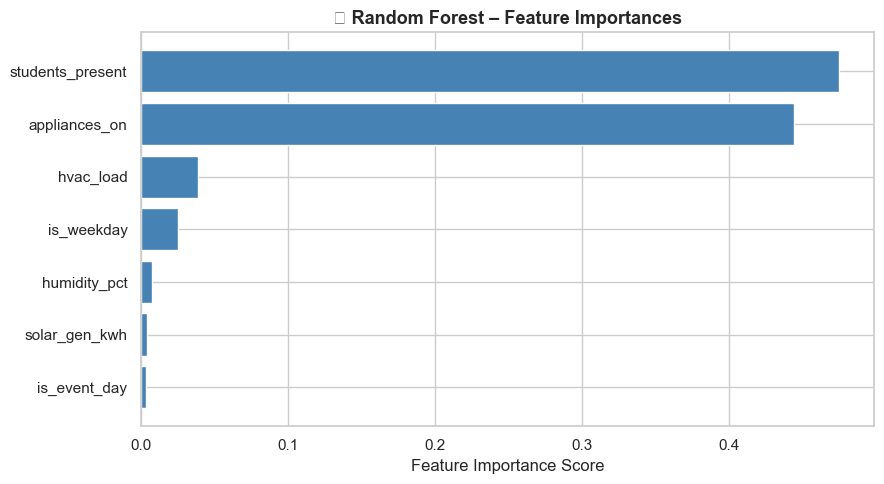


🏆 Feature Importance Ranking:
         Feature  Importance
students_present    0.474880
   appliances_on    0.444539
       hvac_load    0.039062
      is_weekday    0.025254
    humidity_pct    0.007964
   solar_gen_kwh    0.004627
    is_event_day    0.003674


In [18]:
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title(' Random Forest – Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking:")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

In [19]:
def predict_energy(hour, students_present, temperature_C, appliances_on,
                   is_weekday, in_semester, is_event_day, humidity_pct,
                   floor_util_pct, hvac_load, solar_gen_kwh, month, day_of_week):
    """
    Predict energy consumption given institutional conditions.

    Parameters:
    -----------
    hour             : int   — Hour of day (0–23)
    students_present : int   — Number of students on campus
    temperature_C    : float — Ambient temperature (Celsius)
    appliances_on    : int   — Active electrical appliances
    is_weekday       : int   — 1 if weekday, 0 if weekend
    in_semester      : int   — 1 during active academic semester
    is_event_day     : int   — 1 on exam/seminar/fest day
    humidity_pct     : float — Relative humidity (%)
    floor_util_pct   : float — % of building floor area in use
    hvac_load        : float — HVAC demand index (0–10)
    solar_gen_kwh    : float — Solar panel output (kWh)
    month            : int   — Month (1–12)
    day_of_week      : int   — 0=Monday … 6=Sunday

    Returns: dict with predictions from both models
    """
    # Cyclic encode hour
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    raw_input = pd.DataFrame([{
        'students_present': students_present,
        'temperature_C':    temperature_C,
        'appliances_on':    appliances_on,
        'is_weekday':       is_weekday,
        'in_semester':      in_semester,
        'is_event_day':     is_event_day,
        'humidity_pct':     humidity_pct,
        'floor_util_pct':   floor_util_pct,
        'hvac_load':        hvac_load,
        'solar_gen_kwh':    solar_gen_kwh,
        'hour_sin':         hour_sin,
        'hour_cos':         hour_cos,
        'month':            month,
        'day_of_week':      day_of_week
    }])

    scaled_input = pd.DataFrame(
        scaler.transform(raw_input),
        columns=features
    )
    final_input = scaled_input[selected_features]

    lr_pred = lr_model.predict(final_input)[0]
    rf_pred = rf_model.predict(final_input)[0]

    print(f"\n{'='*52}")
    print("  ENERGY USAGE PREDICTION")
    print(f"{'='*52}")
    print(f"   Hour:              {hour}:00   (Month {month}, DoW {day_of_week})")
    print(f"   Students Present:  {students_present}")
    print(f"    Temperature:       {temperature_C} °C   Humidity: {humidity_pct}%")
    print(f"   Appliances On:     {appliances_on}   Floor Util: {floor_util_pct}%")
    print(f"   Semester:          {'Yes' if in_semester else 'No'}   Event Day: {'Yes' if is_event_day else 'No'}")
    print(f"    Solar Generation:  {solar_gen_kwh} kWh   HVAC Load: {hvac_load}")
    print(f"{'='*52}")
    print(f"   Linear Regression: {lr_pred:.2f} kWh")
    print(f"   Random Forest:     {rf_pred:.2f} kWh")
    print(f"{'='*52}")

    return {'linear_regression': round(lr_pred, 2),
            'random_forest':     round(rf_pred, 2)}


# ── Example Predictions ──────────────────────────────────────
print("\n EXAMPLE 1: Tuesday morning, full campus, exam week (Jan)")
result1 = predict_energy(
    hour=10, students_present=700, temperature_C=28,
    appliances_on=60, is_weekday=1, in_semester=1, is_event_day=1,
    humidity_pct=65, floor_util_pct=85, hvac_load=6.0,
    solar_gen_kwh=3.5, month=1, day_of_week=1
)

print("\n EXAMPLE 2: Sunday night, nearly empty campus, vacation (June)")
result2 = predict_energy(
    hour=22, students_present=20, temperature_C=18,
    appliances_on=6, is_weekday=0, in_semester=0, is_event_day=0,
    humidity_pct=40, floor_util_pct=10, hvac_load=1.5,
    solar_gen_kwh=0.0, month=6, day_of_week=6
)



📌 EXAMPLE 1: Tuesday morning, full campus, exam week (Jan)

🔮  ENERGY USAGE PREDICTION
  ⏰ Hour:              10:00   (Month 1, DoW 1)
  👥 Students Present:  700
  🌡️  Temperature:       28 °C   Humidity: 65%
  💡 Appliances On:     60   Floor Util: 85%
  🏫 Semester:          Yes   Event Day: Yes
  ☀️  Solar Generation:  3.5 kWh   HVAC Load: 6.0
  📊 Linear Regression: 60.41 kWh
  🌲 Random Forest:     54.92 kWh

📌 EXAMPLE 2: Sunday night, nearly empty campus, vacation (June)

🔮  ENERGY USAGE PREDICTION
  ⏰ Hour:              22:00   (Month 6, DoW 6)
  👥 Students Present:  20
  🌡️  Temperature:       18 °C   Humidity: 40%
  💡 Appliances On:     6   Floor Util: 10%
  🏫 Semester:          No   Event Day: No
  ☀️  Solar Generation:  0.0 kWh   HVAC Load: 1.5
  📊 Linear Regression: 13.93 kWh
  🌲 Random Forest:     14.51 kWh


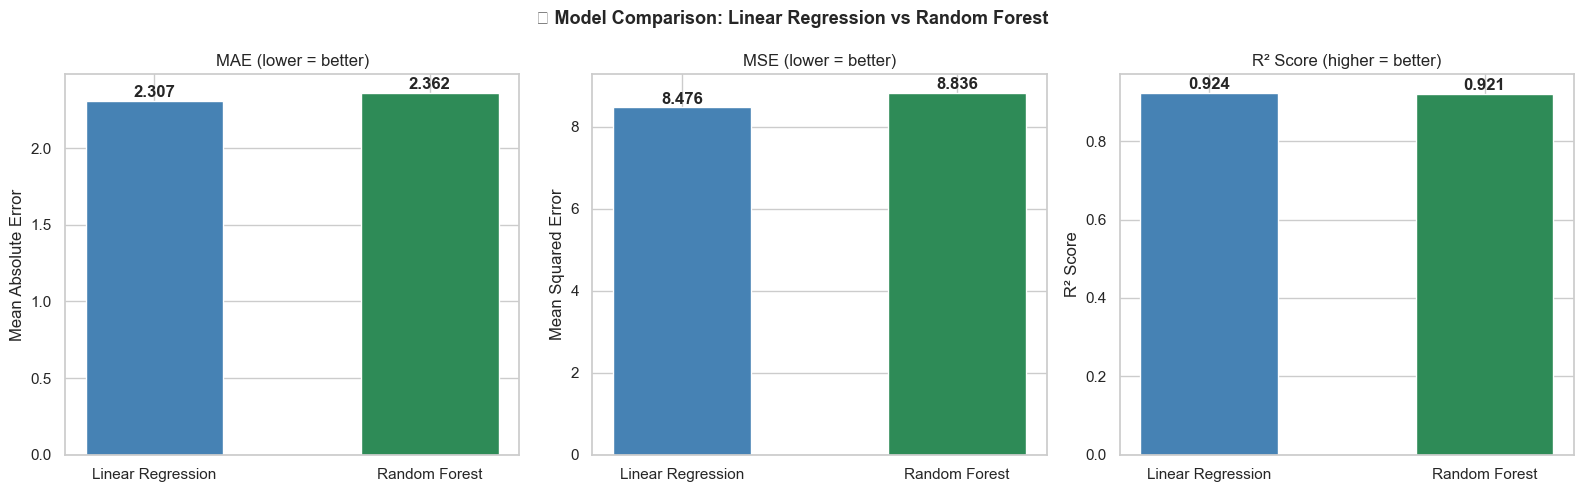


📊 FINAL RESULTS TABLE:
                   Train R²  Test R²     MAE     MSE    RMSE
Model                                                       
Linear Regression    0.9244   0.9239  2.3065  8.4757  2.9113
Random Forest        0.9413   0.9207  2.3619  8.8356  2.9725


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['Linear Regression', 'Random Forest']
mae_vals  = [lr_metrics['MAE'],  rf_metrics['MAE']]
mse_vals  = [lr_metrics['MSE'],  rf_metrics['MSE']]
r2_vals   = [lr_metrics['Test R²'], rf_metrics['Test R²']]
colors    = ['steelblue', 'seagreen']

for ax, vals, title, ylabel in [
    (axes[0], mae_vals,  'MAE (lower = better)',  'Mean Absolute Error'),
    (axes[1], mse_vals,  'MSE (lower = better)',  'Mean Squared Error'),
    (axes[2], r2_vals,   'R² Score (higher = better)', 'R² Score')
]:
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002*max(vals),
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle(' Model Comparison: Linear Regression vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n FINAL RESULTS TABLE:")
print(results_df.round(4))